# Data Preaparation

In [17]:
import pandas as pd
import glob
import os
import re
import matplotlib.pyplot as plt
import numpy as np


EXPERIMENT_DIR = "../experiment"  # adjust if needed
pattern = os.path.join(EXPERIMENT_DIR, "scenario*.csv")

BONUS_DIR = "../experiment"
bonus_pattern = os.path.join(BONUS_DIR, "bonus-scenario*.csv")


In [18]:
dfs = []
for fp in glob.glob(pattern):
    m = re.search(r"scenario(\d+)\.csv", os.path.basename(fp))
    scenario = int(m.group(1)) if m else None
    
    df = pd.read_csv(fp)
    df["scenario"] = scenario
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(all_df)} rows from {len(dfs)} files.")

# Keep only completed vehicles
all_df = all_df[all_df["type"] == "Vehicle"].copy()
all_df["duration"] = pd.to_numeric(all_df["duration"], errors="coerce")
all_df = all_df.dropna(subset=["duration"])

print(f"After filtering, {len(all_df)} rows remain.")

# Replication-level means
rep_df = (all_df
          .groupby(["scenario", "seed", "iteration"], as_index=False)
          .agg(mean_duration=("duration", "mean")))

# Scenario-level mean
scenario_summary = (rep_df
                    .groupby("scenario", as_index=False)
                    .agg(avg_trip_time=("mean_duration", "mean")))

scenario_summary

Loaded 123228 rows from 9 files.
After filtering, 123228 rows remain.


,scenario,avg_trip_time
0,0,288.000000
1,1,288.000000
2,2,288.000000
3,3,291.662309
4,4,294.666662
5,5,346.470254
6,6,413.210036
7,7,435.153720
8,8,571.701287


# Results Visualization: Average Trip Time by Scenario

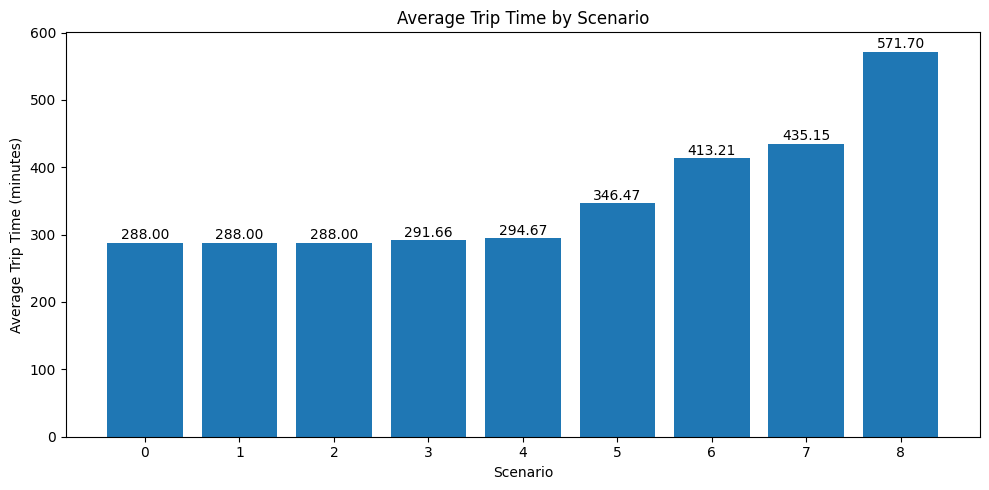

In [19]:
scenario_summary = scenario_summary.sort_values("scenario")

plt.figure(figsize=(10,5))

plt.bar(scenario_summary["scenario"],
        scenario_summary["avg_trip_time"])

# Force all scenario numbers to appear
plt.xticks(scenario_summary["scenario"])

# Add value labels
for i, row in scenario_summary.iterrows():
    plt.text(row["scenario"],
             row["avg_trip_time"] + 5,
             f"{row['avg_trip_time']:.2f}",
             ha='center')

plt.xlabel("Scenario")
plt.ylabel("Average Trip Time (minutes)")
plt.title("Average Trip Time by Scenario")
plt.tight_layout()
plt.show()

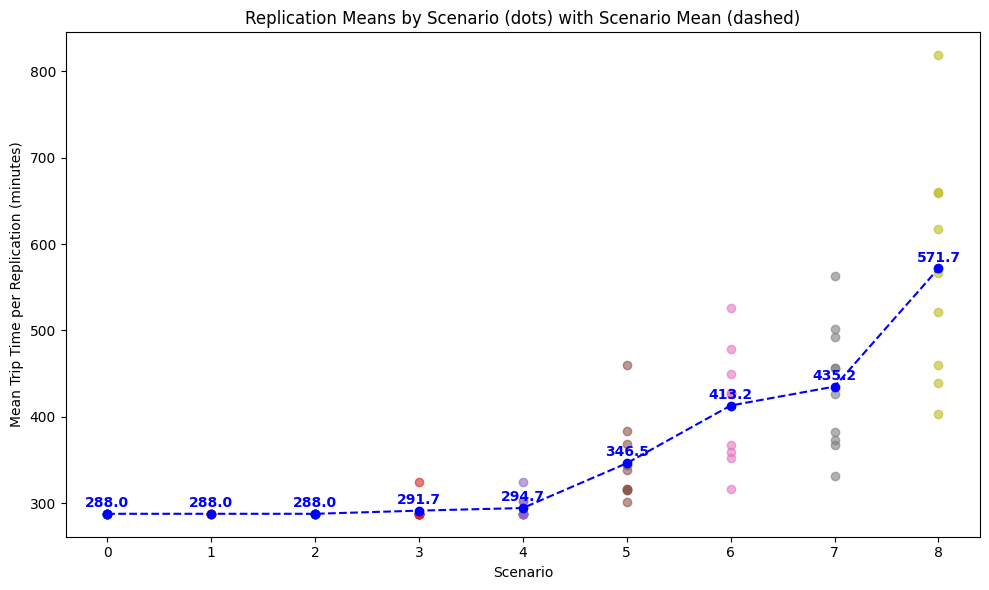

In [20]:
plt.figure(figsize=(10,6))

scenarios = sorted(rep_df["scenario"].unique())

# Plot replication dots
for s in scenarios:
    y = rep_df.loc[rep_df["scenario"] == s, "mean_duration"].values
    x = [s]*len(y)
    plt.scatter(x, y, alpha=0.6)

# Compute scenario means
means = rep_df.groupby("scenario")["mean_duration"].mean()

# Plot mean line
plt.plot(means.index, means.values,
         marker='o',
         linestyle='--',
         color='blue')

# Add mean value labels
for s, m in zip(means.index, means.values):
    plt.text(s,
             m + 8,   # small vertical offset
             f"{m:.1f}",
             ha='center',
             color='blue',
             fontweight='bold')

plt.xticks(scenarios)
plt.xlabel("Scenario")
plt.ylabel("Mean Trip Time per Replication (minutes)")
plt.title("Replication Means by Scenario (dots) with Scenario Mean (dashed)")
plt.tight_layout()
plt.show()

/var/folders/3z/t1bz7z3d0fs08l_5qyn62xlm0000gn/T/ipykernel_52204/4057016475.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


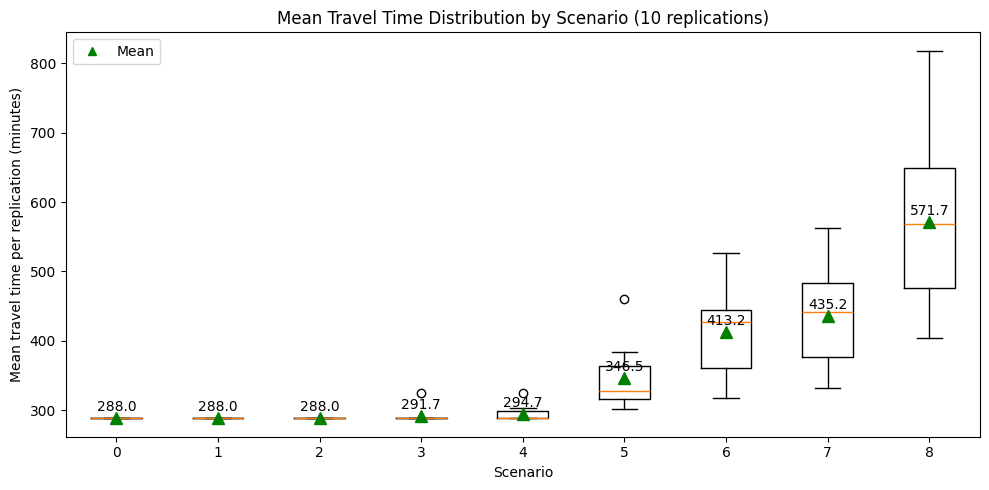

In [21]:
scenarios = sorted(rep_df["scenario"].unique())
data = [rep_df.loc[rep_df["scenario"] == s, "mean_duration"] for s in scenarios]

plt.figure(figsize=(10,5))

# Create boxplot and capture elements
box = plt.boxplot(
    data,
    labels=scenarios,
    showmeans=True,
    meanprops=dict(marker='^',
                   markerfacecolor='green',
                   markeredgecolor='green',
                   markersize=8)
)

# Compute scenario means for labeling
means = [np.mean(d) for d in data]

# Add mean value labels
for i, mean in enumerate(means, start=1):
    plt.text(i,
             mean + 10,   # small vertical offset
             f"{mean:.1f}",
             ha='center',
             color='black')

# Add legend for mean marker
plt.plot([], [], '^', color='green', label='Mean')
plt.legend()

plt.xlabel("Scenario")
plt.ylabel("Mean travel time per replication (minutes)")
plt.title("Mean Travel Time Distribution by Scenario (10 replications)")

plt.tight_layout()
plt.show()

# Bonus Question: Top 5 Bridges to Invest

In [22]:
dfs_bonus = []

for fp in glob.glob(bonus_pattern):
    m = re.search(r"bonus-scenario(\d+)\.csv", os.path.basename(fp))
    scenario = int(m.group(1))
    
    df = pd.read_csv(fp)
    df["scenario"] = scenario
    dfs_bonus.append(df)

bonus_df = pd.concat(dfs_bonus, ignore_index=True)

bonus_df.head()

,lrp,name,total delay,scenario
0,LRP008a,Kachpur bridge,20248.0,8
1,LRP011a,NOYAPARA CULVERT,0.0,8
2,LRP011b,NAYABARI KASPUR BOX CULVERT,0.0,8
3,LRP012a,NAYABARI BOX CULVERT,50848.0,8
4,LRP013a,MADAN PUR (R),49382.0,8


In [23]:
bonus_filtered = bonus_df[bonus_df["scenario"].between(1,7)].copy()

In [24]:
bridge_summary = (
    bonus_filtered
    .groupby(["lrp", "name"], as_index=False)
    .agg(
        avg_delay=("total delay", "mean"),
        total_delay_all=("total delay", "sum")
    )
    .sort_values("avg_delay", ascending=False)
)

bridge_summary.head(10)

,lrp,name,avg_delay,total_delay_all
45,LRP168a,DHOOM GHAT PC GIRDER,78106.857143,546748.0
43,LRP156a,LAMUA BRIDGE,41106.142857,287743.0
55,LRP178a,PURPU DURGAPURE BOX CUL,38319.142857,268234.0
3,LRP012a,NAYABARI BOX CULVERT,21987.571429,153913.0
8,LRP018a,DARIKANDI BRIDGE (R),14817.857143,103725.0
9,LRP020b,SHADIPUR BOX CULVERT,14556.000000,101892.0
37,LRP126a,BOSONTA PUR BOX CULVERT,12122.000000,84854.0
75,LRP224a,Bridge start,9307.285714,65151.0
77,LRP227b,Bridge start,9287.714286,65014.0
63,LRP209a,Bridge start,9238.142857,64667.0


In [25]:
nonzero_bridges = bridge_summary[bridge_summary["avg_delay"] > 0].copy()

nonzero_bridges.head()

,lrp,name,avg_delay,total_delay_all
45,LRP168a,DHOOM GHAT PC GIRDER,78106.857143,546748.0
43,LRP156a,LAMUA BRIDGE,41106.142857,287743.0
55,LRP178a,PURPU DURGAPURE BOX CUL,38319.142857,268234.0
3,LRP012a,NAYABARI BOX CULVERT,21987.571429,153913.0
8,LRP018a,DARIKANDI BRIDGE (R),14817.857143,103725.0


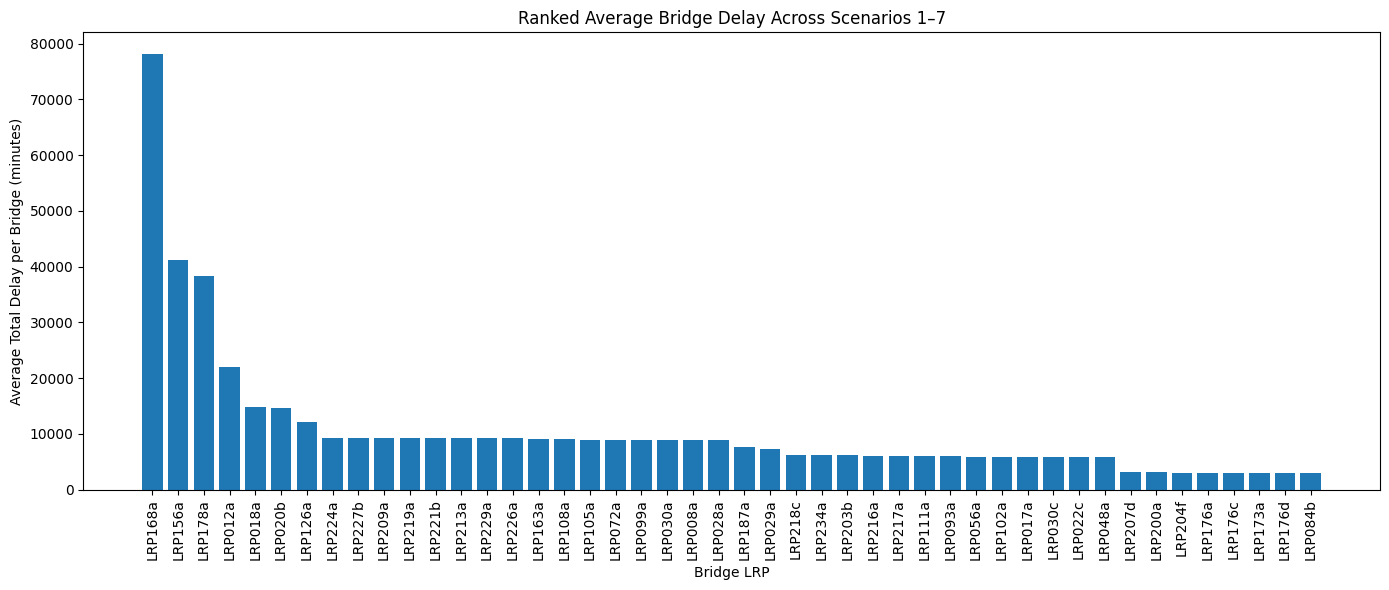

In [26]:
plt.figure(figsize=(14,6))

plt.bar(nonzero_bridges["lrp"], nonzero_bridges["avg_delay"])

plt.xticks(rotation=90)
plt.xlabel("Bridge LRP")
plt.ylabel("Average Total Delay per Bridge (minutes)")
plt.title("Ranked Average Bridge Delay Across Scenarios 1–7")

plt.tight_layout()
plt.show()

In [27]:
top5 = bridge_summary.head(5)
# Create combined label
top5["label"] = top5["lrp"] + " - " + top5["name"]
top5

,lrp,name,avg_delay,total_delay_all,label
45,LRP168a,DHOOM GHAT PC GIRDER,78106.857143,546748.0,LRP168a - DHOOM GHAT PC GIRDER
43,LRP156a,LAMUA BRIDGE,41106.142857,287743.0,LRP156a - LAMUA BRIDGE
55,LRP178a,PURPU DURGAPURE BOX CUL,38319.142857,268234.0,LRP178a - PURPU DURGAPURE BOX CUL
3,LRP012a,NAYABARI BOX CULVERT,21987.571429,153913.0,LRP012a - NAYABARI BOX CULVERT
8,LRP018a,DARIKANDI BRIDGE (R),14817.857143,103725.0,LRP018a - DARIKANDI BRIDGE (R)


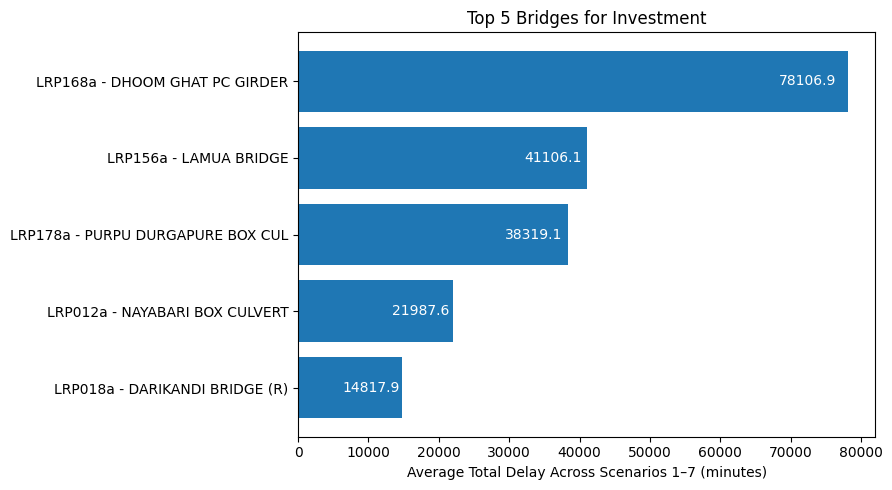

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

bars = plt.barh(top5["label"], top5["avg_delay"])

plt.gca().invert_yaxis()

plt.xlabel("Average Total Delay Across Scenarios 1–7 (minutes)")
plt.title("Top 5 Bridges for Investment")

# Add value labels inside bars
for bar in bars:
    width = bar.get_width()
    plt.text(width * 0.98,  # slightly inside bar
             bar.get_y() + bar.get_height()/2,
             f"{width:.1f}",
             va='center',
             ha='right',
             color='white')   # white for contrast

plt.tight_layout()
plt.show()

In [29]:
df = pd.read_csv("../data/df_road_file.csv")
df["lrp"] = df["lrp"].astype(str)
df.head()

,road,id,model_type,name,lat,lon,length,condition,lrp
0,N1,1000000,source,source,22.358667,91.782277,0,NaN,LRP235b
1,N1,1000001,link,link 1,22.369138,91.777666,1257,NaN,LRP235a
2,N1,1000002,link,link 2,22.369166,91.774194,357,NaN,LRP235
3,N1,1000003,link,link 3,22.376225,91.770543,870,NaN,LRP234b
4,N1,1000004,link,link 4,22.376472,91.770416,30,NaN,LRP234a


In [30]:
# output of charactersitics of the top 5 bridges selected for investment

bridge_names = ["DHOOM GHAT PC GIRDER",
                "LANGOLBANDO PC GIDER BRIDGE",
                "PURPU DURGAPURE BOX CUL",
                "DARIKANDI BRIDGE (R)",
                "SHADIPUR BOX CULVERT"
                ]
top_5_bridges = df[df["name"].isin(bridge_names)]
top_5_bridges.sort_values(by="length", ascending=False)


,road,id,model_type,name,lat,lon,length,condition,lrp
236,N1,1000236,bridge,DHOOM GHAT PC GIRDER,22.915667,91.525944,221,B,LRP168a
598,N1,1000598,bridge,LANGOLBANDO PC GIDER BRIDGE,23.654986,90.575902,160,B,LRP017c
594,N1,1000594,bridge,DARIKANDI BRIDGE (R),23.650889,90.582638,20,B,LRP018a
197,N1,1000197,bridge,PURPU DURGAPURE BOX CUL,22.823944,91.552833,12,C,LRP178a
586,N1,1000586,bridge,SHADIPUR BOX CULVERT,23.634111,90.597027,10,B,LRP020b


In [32]:
bridges_df = df[df["model_type"]=="bridge"]
long_bridges = bridges_df.sort_values(by="length", ascending=False)
long_bridges.head(5)

,road,id,model_type,name,lat,lon,length,condition,lrp
236,N1,1000236,bridge,DHOOM GHAT PC GIRDER,22.915667,91.525944,221,B,LRP168a
598,N1,1000598,bridge,LANGOLBANDO PC GIDER BRIDGE,23.654986,90.575902,160,B,LRP017c
256,N1,1000256,bridge,LAMUA BRIDGE,22.962417,91.441694,94,B,LRP156a
546,N1,1000546,bridge,Bhaber char Bridge(R),23.556444,90.658861,30,A,LRP031b
558,N1,1000558,bridge,Anarpara Bridge (R),23.572166,90.645111,30,A,LRP029a
